In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm, trange
from typing import Optional
from typing import Optional, List
from collections import defaultdict
import sys


In [2]:
def plot_result(total_reward_per_run, regret_per_run, num_episodes , num_runs, figsize = (15,4), title = '', color = 'blue'):

  fig, axs = plt.subplots(2, 1, figsize = figsize)

  # Total_reward
  axs[0].set_title('Reward')
  mean_total_reward_per_run = np.mean(np.array(total_reward_per_run), axis = 0)
  std_total_reward_per_run = np.std(np.array(total_reward_per_run), axis = 0)
  up_bound_total_reward = mean_total_reward_per_run + 1.96 * std_total_reward_per_run/np.sqrt(num_runs)
  low_bound_total_reward = mean_total_reward_per_run - 1.96 * std_total_reward_per_run/np.sqrt(num_runs)
  axs[0].plot(range(num_episodes), mean_total_reward_per_run, label = 'Total_Reward', color = color)
  axs[0].fill_between(range(num_episodes), low_bound_total_reward, up_bound_total_reward, alpha = 0.5, color = color)
# axs[0].set_xlabel('episode')
  axs[0].set_ylabel('Total Reward')
  
  

  # Regret
  axs[1].set_title('Regret')
  mean_regret_per_run = np.mean(np.array(regret_per_run), axis = 0)
  std_regret_per_run = np.std(np.array(regret_per_run), axis = 0)
  up_bound_regret = mean_regret_per_run + 1.96 * std_regret_per_run/np.sqrt(num_runs)
  low_bound_regret = mean_regret_per_run - 1.96 * std_regret_per_run/np.sqrt(num_runs)
  axs[1].plot(range(num_episodes), mean_regret_per_run, label = 'Regret', color = color)
  axs[1].fill_between(range(num_episodes),low_bound_regret, up_bound_regret, alpha = 0.5, color = color)
  # axs[1].set_xlabel('episode')
  axs[1].set_ylabel('Regret')

  # plt.ylabel('Reward')
  fig.suptitle(title)
  plt.xlabel('episode')
  plt.legend()
  plt.show()


def random_policy(nA):
      A = np.ones(nA, dtype=float) / nA
      def policy_fn(observation):
          return A
      return policy_fn



In [3]:
def compare_result(total_reward_per_run_1, total_reward_per_run_2,
                   regret_per_run_1, regret_per_run_2,
                   num_episodes , num_runs, figsize = (15,4), title = '',
                   lable1='', lable2=''):

  fig, axs = plt.subplots(2, 1, figsize = figsize)

  # Total_reward
  axs[0].set_title('Reward')
  mean_total_reward_per_run_1 = np.mean(np.array(total_reward_per_run_1), axis = 0)
  std_total_reward_per_run_1 = np.std(np.array(total_reward_per_run_1), axis = 0)
  up_bound_total_reward_1 = mean_total_reward_per_run_1 + 1.96 * std_total_reward_per_run_1/np.sqrt(num_runs)
  low_bound_total_reward_1 = mean_total_reward_per_run_1 - 1.96 * std_total_reward_per_run_1/np.sqrt(num_runs)
  mean_total_reward_per_run_2 = np.mean(np.array(total_reward_per_run_2), axis = 0)
  std_total_reward_per_run_2 = np.std(np.array(total_reward_per_run_2), axis = 0)
  up_bound_total_reward_2 = mean_total_reward_per_run_2 + 1.96 * std_total_reward_per_run_2/np.sqrt(num_runs)
  low_bound_total_reward_2 = mean_total_reward_per_run_2 - 1.96 * std_total_reward_per_run_2/np.sqrt(num_runs)
  
  axs[0].plot(range(num_episodes), mean_total_reward_per_run_1, label = lable1, color = 'blue')
  axs[0].fill_between(range(num_episodes), low_bound_total_reward_1, up_bound_total_reward_1, alpha = 0.5, color = 'blue')
  axs[0].plot(range(num_episodes), mean_total_reward_per_run_2, label = lable2, color = 'red')
  axs[0].fill_between(range(num_episodes), low_bound_total_reward_2, up_bound_total_reward_2, alpha = 0.5, color = 'red')
# axs[0].set_xlabel('episode')
  axs[0].set_ylabel('Total Reward')
  
  

  # Regret
  axs[1].set_title('Regret')
  mean_regret_per_run_1 = np.mean(np.array(regret_per_run_1), axis = 0)
  std_regret_per_run_1 = np.std(np.array(regret_per_run_1), axis = 0)
  up_bound_regret_1 = mean_regret_per_run_1 + 1.96 * std_regret_per_run_1/np.sqrt(num_runs)
  low_bound_regret_1 = mean_regret_per_run_1 - 1.96 * std_regret_per_run_1/np.sqrt(num_runs)
  mean_regret_per_run_2 = np.mean(np.array(regret_per_run_2), axis = 0)
  std_regret_per_run_2 = np.std(np.array(regret_per_run_2), axis = 0)
  up_bound_regret_2 = mean_regret_per_run_2 + 1.96 * std_regret_per_run_2/np.sqrt(num_runs)
  low_bound_regret_2 = mean_regret_per_run_2 - 1.96 * std_regret_per_run_2/np.sqrt(num_runs)

  axs[1].plot(range(num_episodes), mean_regret_per_run_1, label = lable1, color = 'blue')
  axs[1].fill_between(range(num_episodes),low_bound_regret_1, up_bound_regret_1, alpha = 0.5, color = 'blue')
  axs[1].plot(range(num_episodes), mean_regret_per_run_2, label = lable2, color='red')
  axs[1].fill_between(range(num_episodes),low_bound_regret_2, up_bound_regret_2, alpha = 0.5,color='red')
  axs[1].set_ylabel('Regret')

  fig.suptitle(title)
  plt.xlabel('episode')
  plt.legend()
  plt.show()



In [4]:
def cumulative_regret(regret_per_run):
  # Calculate the cumulative sum for each inner list separately
  cumulative_regret_per_run = []
  for inner_list in regret_per_run:
      cumulative_sum = 0
      cumulative_regret = []
      for value in inner_list:
          cumulative_sum += value
          cumulative_regret.append(cumulative_sum)
      cumulative_regret_per_run.append(cumulative_regret)
  return cumulative_regret_per_run

In [5]:
env = gym.make('CliffWalking-v0')

In [6]:
class SARSA:

  def __init__(self, env, learning_rate = 0.1, discount = 0.99, epsilon = 1, epsilon_decay:Optional[float]= None):

    self.env = env
    self.state_size = env.observation_space.n
    self.action_space = env.action_space
    self.action_size = env.action_space.n
    self.q_table = np.zeros((self.state_size, self.action_size))

    self.learning_rate = learning_rate
    self.discount = discount
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay
    self.epsilon_min = 0.001


  def get_action(self, state):
    if np.random.rand() < self.epsilon:
      return env.action_space.sample()
    else:
      return np.argmax(self.q_table[state])

  def train(self, episodes):

    regrets = []
    total_rewards = []
    frames = []

    for episode in range(episodes):

      state, _ = self.env.reset()
      action = self.get_action(state)
      total_reward = 0
      frames_per_episode = []

      while True:

        next_state, reward, terminated, truncated, _  = self.env.step(action)
        next_action = self.get_action(next_state)

        current_q = self.q_table[state, action]
        next_q = self.q_table[next_state, next_action]

        new_q = current_q + self.learning_rate * (reward + self.discount * next_q - current_q)
        self.q_table[state , action] = new_q


        total_reward += reward
        state = next_state
        action = next_action
        
        # if episode == 950:
          # print()
        if terminated or truncated:
          regret = -13 - total_reward
          regrets.append(regret)
          total_rewards.append(total_reward)
          break

        if episode % 20 == 0:
          frames_per_episode.append(self.env.render())

      if frames_per_episode:
        frames.append(frames_per_episode)

      if (self.epsilon_decay) and (self.epsilon > self.epsilon_min):
        self.epsilon = self.epsilon * self.epsilon_decay

    return regrets, total_rewards, frames
  
  

Running:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\MSI\AppData\Local\Programs\Python\Python39\lib\site-packages\gymnasium\envs\toy_text\cliffwalking.py:218: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CliffWalking-v0", render_mode="rgb_array")
  gym.logger.warn(


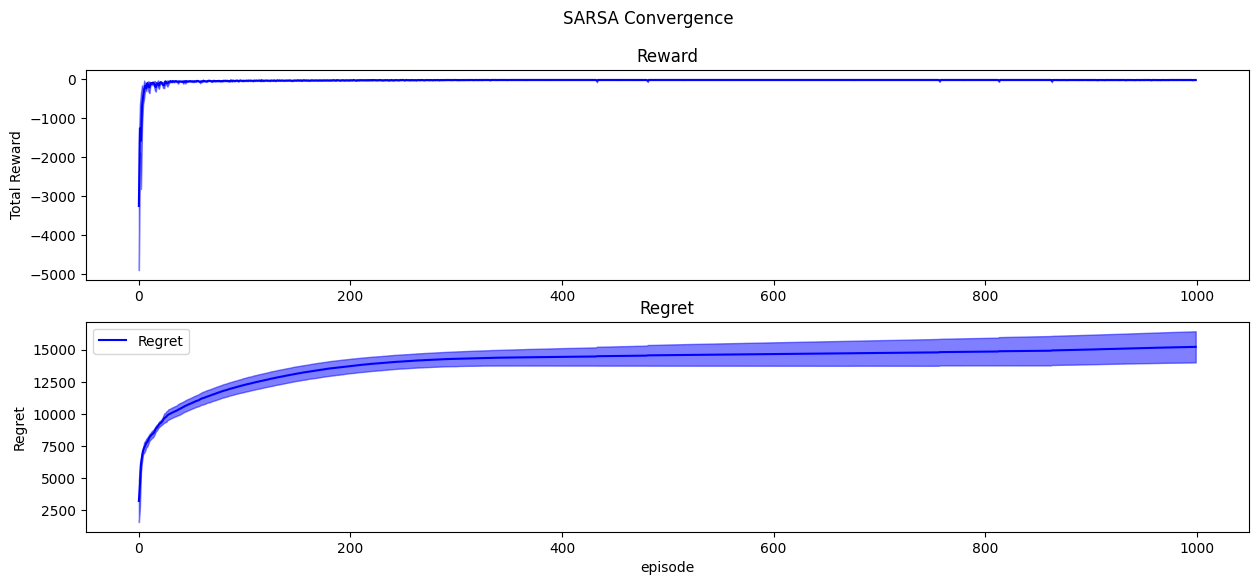

In [7]:
num_runs = 5
num_episodes = 1000

learning_rate = 0.1
discount = 0.9
epsilon = 0.5
epsilon_decay = 0.9

regret_per_run_sarsa = []
total_reward_per_run_sarsa =[]

for _ in tqdm(range(num_runs), desc = 'Running'):
  env.reset()
  agent = SARSA(env, learning_rate, discount, epsilon, epsilon_decay)
  regret, total_reward, frames = agent.train(num_episodes)

  regret_per_run_sarsa.append(regret)
  total_reward_per_run_sarsa.append(total_reward)
  
cumulative_regret_per_run_sarsa = cumulative_regret(regret_per_run_sarsa)

plot_result(total_reward_per_run_sarsa, cumulative_regret_per_run_sarsa, num_episodes , num_runs,
              figsize = (15, 6), title = 'SARSA Convergence', color='blue')

In [7]:
class n_step_tree_backup:

  def __init__(self, env, learning_rate = 0.1, discount = 0.99, epsilon = 1, epsilon_decay:Optional[float]= None, n=0):

    self.env = env
    self.state_size = env.observation_space.n
    self.action_space = env.action_space
    self.action_size = env.action_space.n
    self.q_table = np.zeros((self.state_size, self.action_size))

    self.learning_rate = learning_rate
    self.discount = discount
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay
    self.epsilon_min = 0.01
    self.n = n

  def get_action(self, state):
    if np.random.rand() < self.epsilon:
      return env.action_space.sample()
    else:
      return np.argmax(self.q_table[state])

  def train(self, episodes):

    regrets = []
    total_rewards = []
    frames = []

    for episode in range(episodes):

      state, _ = self.env.reset()
      action = self.get_action(state)
      total_reward = 0
      frames_per_episode = []
      step_cnt = 0
      while True:
        step_cnt += 1
        next_state, reward, terminated, truncated, _  = self.env.step(action)
        # if terminated and total_reward > -13:
        #   terminated = False
        next_action = self.get_action(next_state)
        # if step_cnt > 500:
        #   truncated =True
        current_q = self.q_table[state, action]
        if self.n == 0: # Its SARSA
          next_q = self.q_table[next_state, next_action]
          # continue

        elif self.n == 1: # Its one-step tree backup
          # if next_state == 47:
          #   self.n -= 1
          other_actions_sum = sum(self.q_table[next_state, :]) - self.q_table[next_state, next_action]
          next_q = (1-self.epsilon) * self.q_table[next_state, next_action] + self.epsilon * other_actions_sum

        elif self.n == 2: # Its two-step tree backup
          # i need next_next_action and next_next_state
          next_next_state, next_reward, _, _, _  = self.env.step(next_action)
          if next_next_state == 47:
            self.n -= 1
          next_next_action = self.get_action(next_next_state)

          next_other_actions_sum = sum(self.q_table[next_next_state, :]) - self.q_table[next_next_state, next_next_action]
          next_next_q = (1-self.epsilon) * self.q_table[next_next_state, next_next_action] + self.epsilon * next_other_actions_sum

          other_actions_sum = sum(self.q_table[next_state, :]) - self.q_table[next_state, next_action]
          next_q = (1-self.epsilon) * next_next_q + self.epsilon * other_actions_sum  
        
        elif self.n == 3:  # It's three-step tree backup
          # Step 1: Take action from the current state
          next_next_state, next_reward, _, _, _ = self.env.step(next_action)
          
          # Step 2: If the next_next_state is terminal or the episode should end
          if next_next_state == 46:  # Assuming 47 is a terminal state
              self.n -= 1
          
          next_next_action = self.get_action(next_next_state)
          next_next_next_state, reward_next_next, _, _, _ = self.env.step(next_next_action)
          
          if next_next_next_state == 47:  # Terminal state check
              self.n -= 1
              
          next_next_next_action = self.get_action(next_next_next_state)
          next_other_actions_sum = sum(self.q_table[next_next_state, :]) - self.q_table[next_next_state, next_next_next_action]
          next_next_q = (1 - self.epsilon) * self.q_table[next_next_state, next_next_next_action] + self.epsilon * next_other_actions_sum
          other_actions_sum = sum(self.q_table[next_state, :]) - self.q_table[next_state, next_action]
          next_q = (1 - self.epsilon) * next_next_q + self.epsilon * other_actions_sum 

        new_q = current_q + self.learning_rate * (reward + self.discount * next_q - current_q)
        self.q_table[state , action] = new_q
        
        
        
        # if reward != -1 or reward != -100:
        #   print()
        total_reward += reward
        state = next_state
        action = next_action
        
        
        if terminated or truncated:
          # if total_reward > -11:
          #   print()
          regret = -13 - total_reward
          regrets.append(regret)
          total_rewards.append(total_reward)
          break

        if episode % 20 == 0:
          frames_per_episode.append(self.env.render())

      if frames_per_episode:
        frames.append(frames_per_episode)

      if (self.epsilon_decay) and (self.epsilon > self.epsilon_min):
        self.epsilon = self.epsilon * self.epsilon_decay

    return regrets, total_rewards, frames
  


Running:   0%|          | 0/5 [00:00<?, ?it/s]

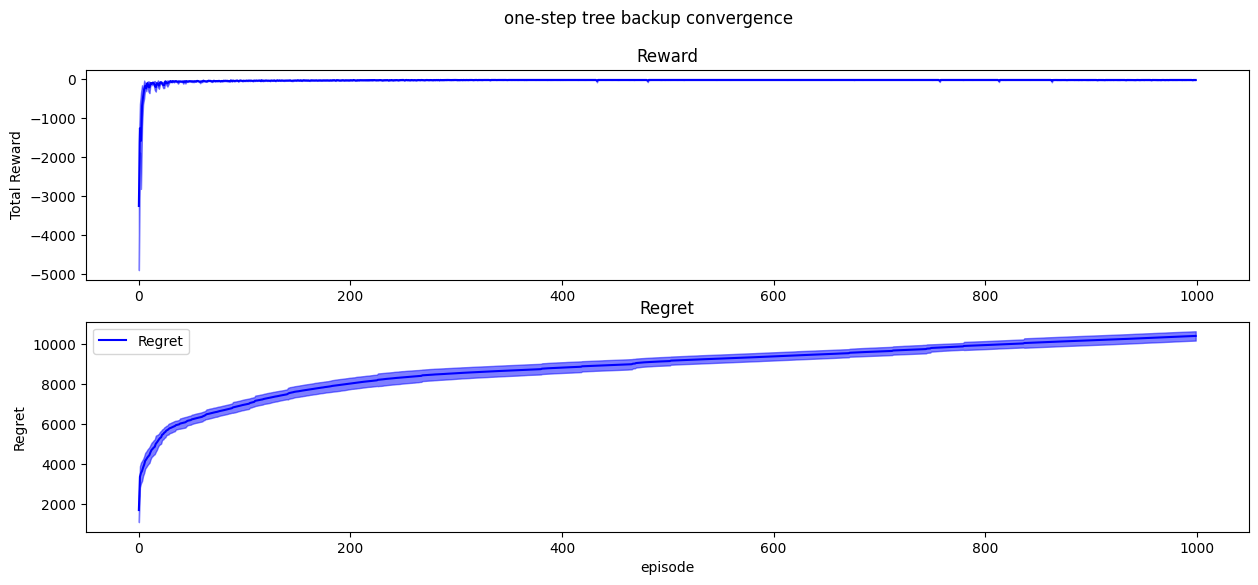

In [24]:
# ________________one step tree backup___________#
n = 1
num_runs = 5
num_episodes = 1000

learning_rate = 0.1
discount = 0.9
epsilon = 0.5
epsilon_decay = 0.9

regret_per_run_one_step = []
total_reward_per_run_one_step =[]

for _ in tqdm(range(num_runs), desc = 'Running'):
  env.reset()
  agent = n_step_tree_backup(env, learning_rate, discount, epsilon, epsilon_decay, n=n)
  regret, total_reward, frames = agent.train(num_episodes)

  regret_per_run_one_step.append(regret)
  total_reward_per_run_one_step.append(total_reward)
  
cumulative_regret_per_run_one_step = cumulative_regret(regret_per_run_one_step)

plot_result(total_reward_per_run_sarsa, cumulative_regret_per_run_one_step, num_episodes , num_runs,
              figsize = (15, 6), title = 'one-step tree backup convergence', color='blue')

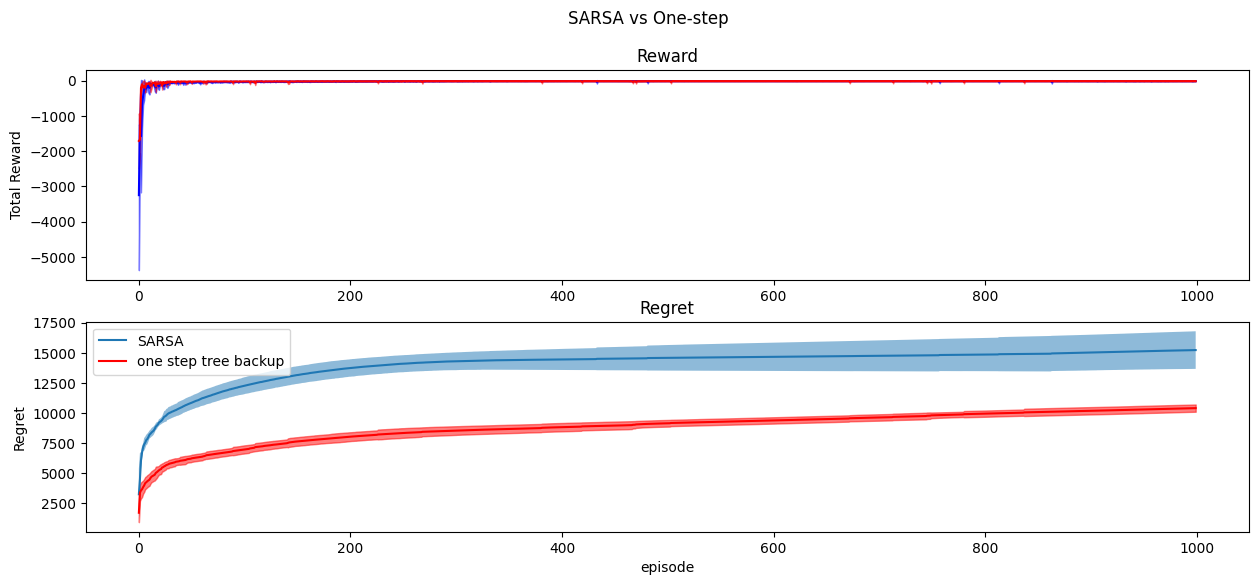

In [30]:
compare_result(total_reward_per_run_sarsa, total_reward_per_run_one_step,
               cumulative_regret_per_run_sarsa, cumulative_regret_per_run_one_step,
                num_episodes , num_runs,
              figsize = (15, 6), title = 'SARSA vs One-step', lable1='SARSA', lable2='one step tree backup')

Running:   0%|          | 0/3 [00:00<?, ?it/s]

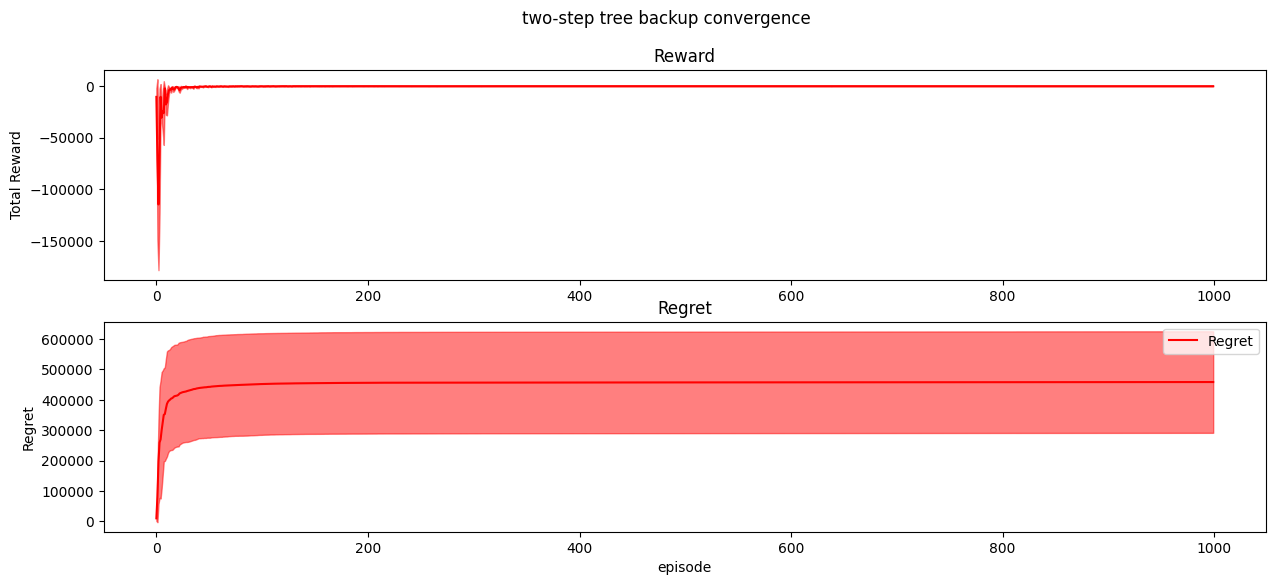

In [25]:
# ________________two step backup___________#

n = 2

num_runs = 3
num_episodes = 1000

learning_rate = 0.1
discount = 0.9
epsilon = 1
epsilon_decay = 0.99

regret_per_run_two_step = []
total_reward_per_run_two_step =[]

for _ in tqdm(range(num_runs), desc = 'Running'):
  env.reset()
  agent = n_step_tree_backup(env, learning_rate, discount, epsilon, epsilon_decay, n=n)
  regret, total_reward, frames = agent.train(num_episodes)

  regret_per_run_two_step.append(regret)
  total_reward_per_run_two_step.append(total_reward)
  
cumulative_regret_per_run_two_step = cumulative_regret(regret_per_run_two_step)

plot_result(total_reward_per_run_two_step, cumulative_regret_per_run_two_step, num_episodes , num_runs,
              figsize = (15, 6), title = 'two-step tree backup convergence', color='red')
  

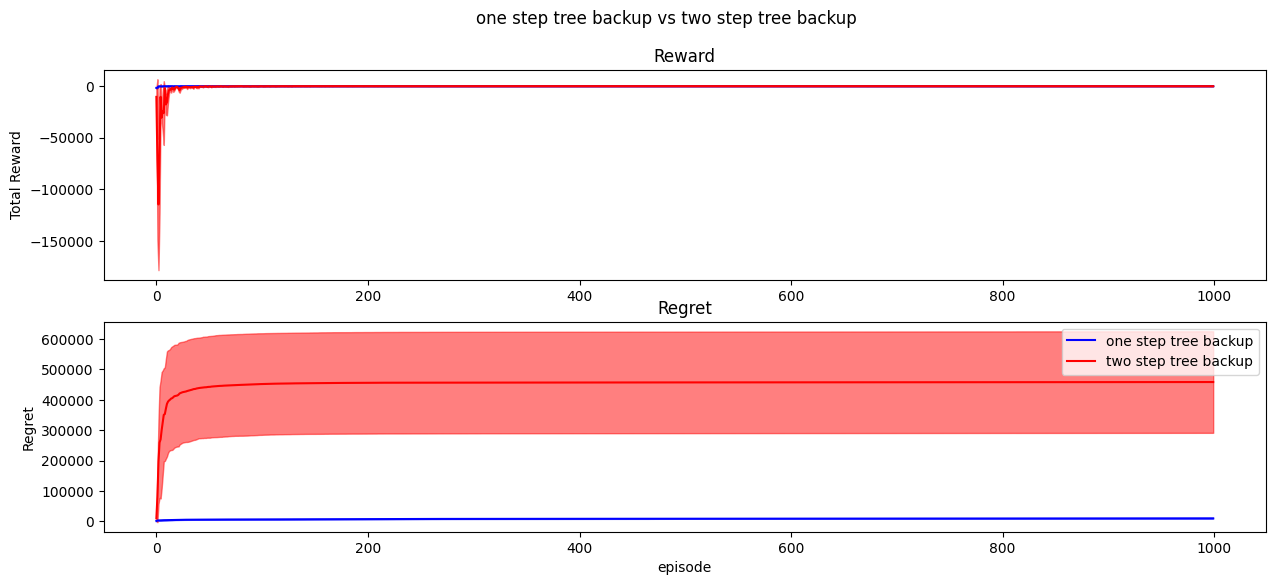

In [45]:
compare_result(total_reward_per_run_one_step, total_reward_per_run_two_step,
               cumulative_regret_per_run_one_step, cumulative_regret_per_run_two_step,
                num_episodes , num_runs,
              figsize = (15, 6), title = 'one step tree backup vs two step tree backup', lable1='one step tree backup', lable2='two step tree backup')

Running:   0%|          | 0/3 [00:00<?, ?it/s]

C:\Users\MSI\AppData\Local\Programs\Python\Python39\lib\site-packages\gymnasium\envs\toy_text\cliffwalking.py:218: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CliffWalking-v0", render_mode="rgb_array")
  gym.logger.warn(


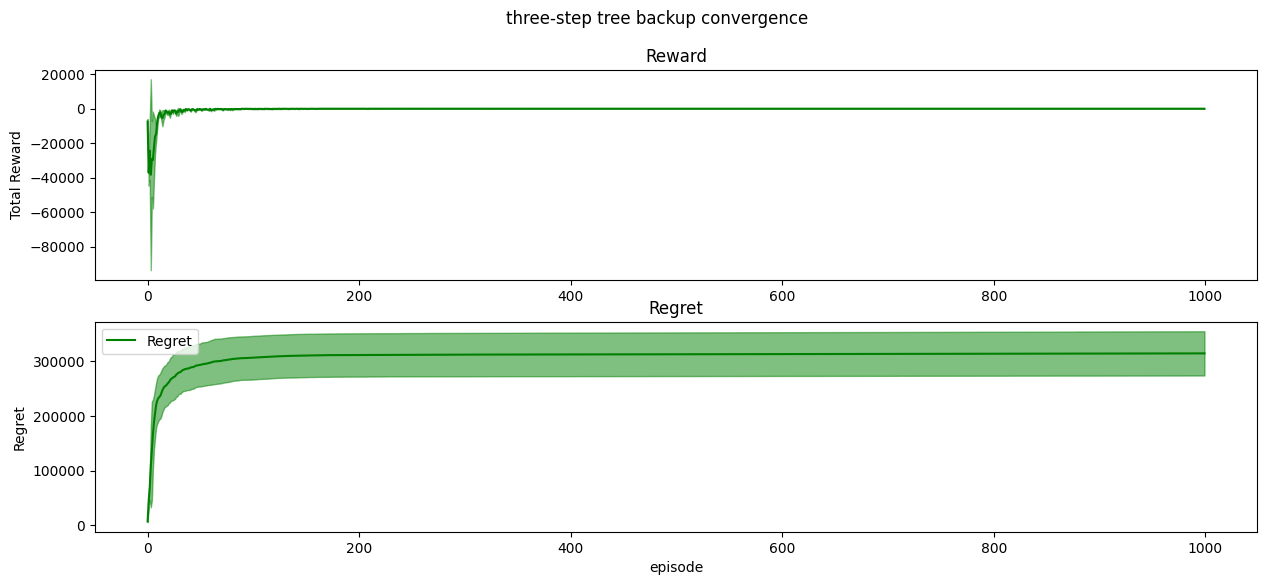

In [8]:
# ________________three step backup___________#

n = 3

num_runs = 3
num_episodes = 1000

learning_rate = 0.1
discount = 0.9
epsilon = 1
epsilon_decay = 0.99

regret_per_run_three_step = []
total_reward_per_run_three_step =[]

for _ in tqdm(range(num_runs), desc = 'Running'):
  env.reset()
  agent = n_step_tree_backup(env, learning_rate, discount, epsilon, epsilon_decay, n=n)
  regret, total_reward, frames = agent.train(num_episodes)

  regret_per_run_three_step.append(regret)
  total_reward_per_run_three_step.append(total_reward)
  
cumulative_regret_per_run_three_step = cumulative_regret(regret_per_run_three_step)

plot_result(total_reward_per_run_three_step, cumulative_regret_per_run_three_step, num_episodes , num_runs,
              figsize = (15, 6), title = 'three-step tree backup convergence', color='green')
  

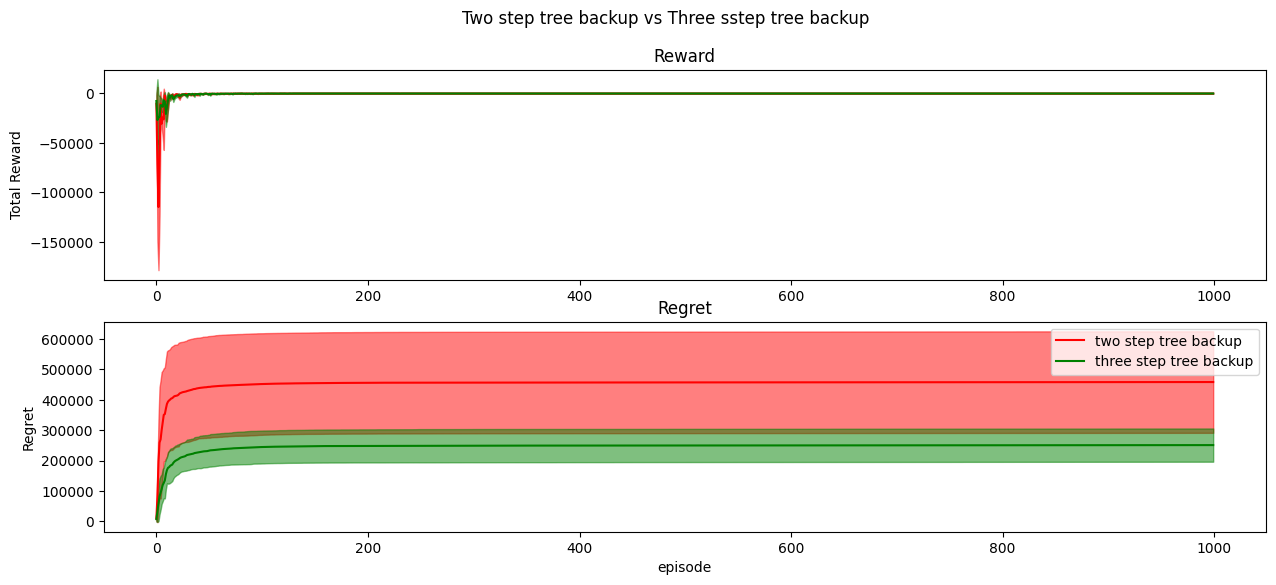

In [41]:
compare_result(total_reward_per_run_two_step, total_reward_per_run_three_step,
               cumulative_regret_per_run_two_step, cumulative_regret_per_run_three_step,
                num_episodes , num_runs,
              figsize = (15, 6), title = 'Two step tree backup vs Three sstep tree backup', lable1='two step tree backup', lable2='three step tree backup')